# Customer Churn Prediction
Classification pipeline flagging telecom accounts likely to cancel. Logistic Regression vs.
Random Forest, evaluated with a confusion matrix and ROC-AUC. The trained Random Forest is
saved to `model.pkl` and reused by the Streamlit app in `../09-churn-streamlit-app`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, accuracy_score)

df = pd.read_csv('data/telecom_churn.csv')
print(df.shape)
df['churn'].value_counts(normalize=True).round(3)

(3000, 9)


churn
0    0.667
1    0.333
Name: proportion, dtype: float64

## 1. Encode categorical features

In [2]:
data = df.copy()
cat_cols = ['contract_type', 'internet_service', 'tech_support', 'payment_method', 'paperless_billing']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

X = data.drop(columns=['churn'])
y = data['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

## 2. Baseline: Logistic Regression

In [3]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)
pred_log = logreg.predict(X_test_s)
proba_log = logreg.predict_proba(X_test_s)[:, 1]
print(classification_report(y_test, pred_log, target_names=['Stayed', 'Churned']))
print('ROC-AUC:', round(roc_auc_score(y_test, proba_log), 3))

              precision    recall  f1-score   support

      Stayed       0.76      0.81      0.79       400
     Churned       0.57      0.49      0.53       200

    accuracy                           0.71       600
   macro avg       0.67      0.65      0.66       600
weighted avg       0.70      0.71      0.70       600

ROC-AUC: 0.759


## 3. Random Forest Classifier

In [4]:
rf = RandomForestClassifier(n_estimators=400, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, pred_rf)
auc = roc_auc_score(y_test, proba_rf)
print(classification_report(y_test, pred_rf, target_names=['Stayed', 'Churned']))
print(f'Accuracy: {acc:.3f}   ROC-AUC: {auc:.3f}')

              precision    recall  f1-score   support

      Stayed       0.72      0.82      0.77       400
     Churned       0.51      0.38      0.43       200

    accuracy                           0.67       600
   macro avg       0.62      0.60      0.60       600
weighted avg       0.65      0.67      0.66       600

Accuracy: 0.670   ROC-AUC: 0.736


## 4. Confusion matrix

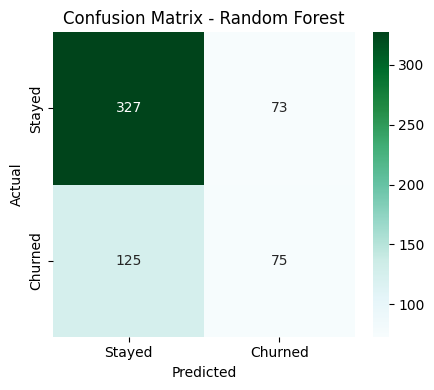

In [5]:
cm = confusion_matrix(y_test, pred_rf)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn', xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.savefig('churn_confusion_matrix.png', dpi=110)
plt.show()

## 5. ROC curve

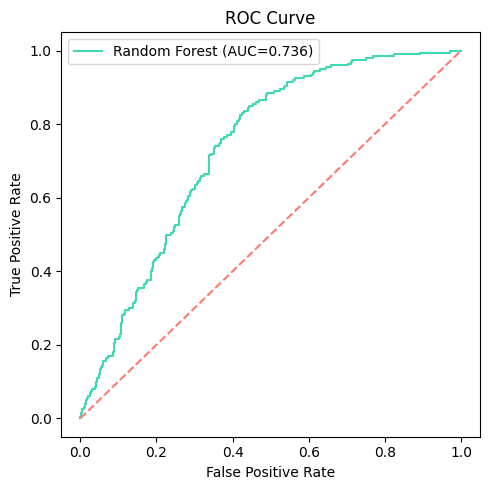

In [6]:
fpr, tpr, _ = roc_curve(y_test, proba_rf)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, color='#3FD8B4', label=f'Random Forest (AUC={auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', color='#FF7A6E')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend(); plt.title('ROC Curve')
plt.tight_layout()
plt.savefig('churn_roc_curve.png', dpi=110)
plt.show()

## 6. Feature importance -> retention actions

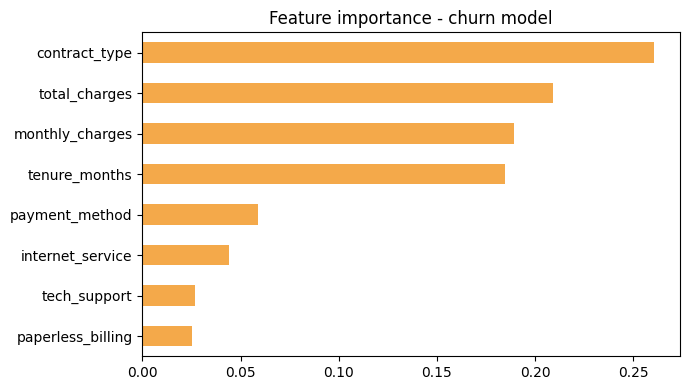

contract_type      0.260815
total_charges      0.209300
monthly_charges    0.189328
tenure_months      0.184838
payment_method     0.059141
dtype: float64

In [7]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7,4))
imp.plot(kind='barh', color='#F4A94A')
plt.title('Feature importance - churn model')
plt.tight_layout()
plt.savefig('churn_feature_importance.png', dpi=110)
plt.show()
imp.sort_values(ascending=False).head(5)

**Business translation of top features:**
1. `contract_type` — month-to-month customers churn far more than annual contracts -> incentivize longer contracts with a discount.
2. `tenure_months` — churn risk is highest in the first year -> build an onboarding/check-in flow for new customers.
3. `tech_support` — customers without tech support churn more -> bundle a free trial of tech support for at-risk accounts.

## 7. Save the model for the Streamlit app

In [8]:
with open('model.pkl', 'wb') as f:
    pickle.dump({'model': rf, 'scaler': scaler, 'encoders': encoders, 'feature_order': list(X.columns)}, f)

import shutil, os
os.makedirs('../09-churn-streamlit-app/model', exist_ok=True)
shutil.copy('model.pkl', '../09-churn-streamlit-app/model/model.pkl')
print('Model saved and copied to the Streamlit app folder.')

Model saved and copied to the Streamlit app folder.
